# How to apply the addressing scheme

This notebook is a direct port of HexagDLy's own `how_to_apply_adressing_scheme.ipynb` -- and almost nothing changes in the port, because this step is **backend-independent**. Mapping the Cartesian x-y coordinates of a hexagonal detector to the indices of a 2D matrix has nothing to do with PyTorch, Keras, or any other framework; it has to be done once, on the data, before either `hexagdly.Conv2d` or `keras_hexagdly.Conv2d` ever sees it.

Hexagonally sampled data can have different appearances. One is an image where each pixel is hexagonal instead of square (e.g. some optical/IACT cameras); another is a hexagonal detector grid not even meant to represent images (e.g. some particle detectors). In both cases, the data points are arranged on a hexagonal lattice and need to be mapped onto a square-tensor index before any of `keras_hexagdly`'s layers can be applied.

In [1]:
%matplotlib inline
import numpy as np
import addressing_utils as au
import matplotlib.pyplot as plt

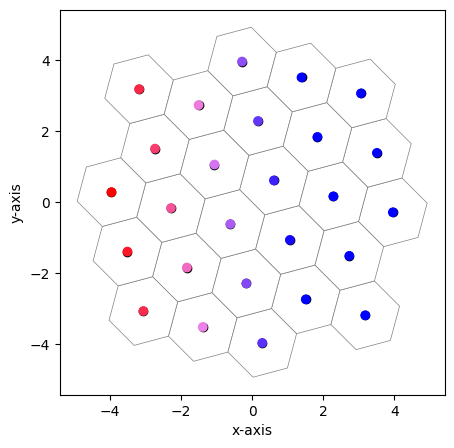

In [2]:
mydetector = au.Detector()
r, a = mydetector.r, mydetector.a
x, y = mydetector.x, mydetector.y

plt.figure('Original Cartesian layout', figsize=(5, 5))
ax = plt.gca()
au.plot(ax, x, y, hexagons=True)

## First step

At first, we need to rotate the coordinates such that we find vertically aligned detectors, which will define columns. Therefore, we shift the origin of the coordinate system to the position of one of the detectors and rotate the coordinates around it.

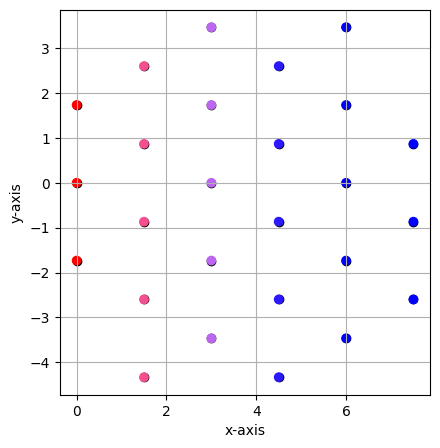

In [3]:
x, y = x - x[0], y - y[0]
radius = np.sqrt(x ** 2 + y ** 2)
theta = np.arctan2(y, x)
rotation = mydetector.rotation_angle
x, y = radius * np.cos(theta - rotation), radius * np.sin(theta - rotation)

plt.figure('rotated', figsize=(5, 5))
au.plot(plt.gca(), x, y, grid=True)

## Second step

The next step is to align the detectors horizontally, which will define rows. This is done by shifting every second column **upwardly** by the length of $r$.

**Note**: It is important that those columns are shifted upwardly, not downwardly, for the addressing scheme (and therefore both HexagDLy and keras_hexagdly) to make proper calculations.

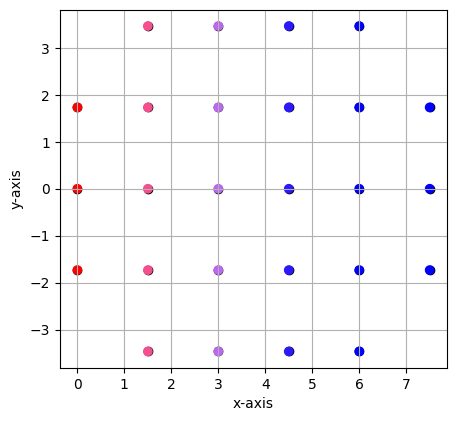

In [4]:
y = np.where(np.mod(np.round((x - x.min()) / (1.5 * a)), 2) == 1, y + r, y)
plt.figure('aligned', figsize=(5, 5))
au.plot(plt.gca(), x, y, grid=True)

## Third step

Lastly, we want the indices of the 2D matrix to be positive integers, counting rows from top to bottom and columns from left to right. Thus, we shift the origin of the coordinates again and scale them by $1.5a$ along the x-axis and by $2r$ along the y-axis, respectively.

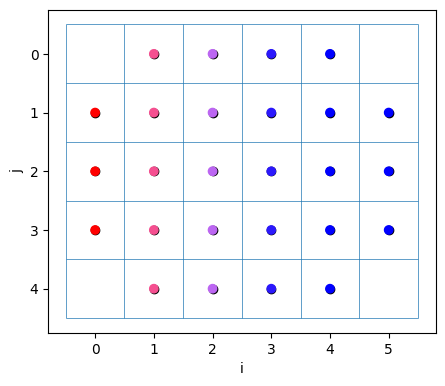

In [5]:
i, j = np.round((x - x.min()) / (1.5 * a)), np.round((-1 * (y - y.max())) / (2 * r))
plt.figure('indexed', figsize=(5, 5))
ax = plt.gca()
au.plot(ax, i, j, lines=True)
ax.invert_yaxis()

`(i, j)` are now the column/row indices of a square tensor: build a `(1, H, W, 1)` channels-last array (or `(1, C, H, W)` for PyTorch HexagDLy) by placing each detector's value at `tensor[0, j, i, 0]`, leaving any unused cell at `0`. That tensor is the input `keras_hexagdly.Conv2d`/`MaxPool2d` expect -- see `keras_hexagdly_2d_example.ipynb`.